# Step 2 —  Load the single-cell gene-expression count matrix


"Does Secretory expression carry severity signal in general?" before zooming into "which Secretory state drives it?"

## 1.1 — Install / import dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
sc.settings.verbosity = 1  # 0=silent, 1=info, 2=warnings, 3=hints

## 1.2 — Load the .h5ad file



In [ ]:
H5AD_PATH = r"C:\Users\marya\Downloads\projecttt\Variant_Vax_obj.h5ad"

adata = sc.read_h5ad(H5AD_PATH)
print(adata)

AnnData object with n_obs × n_vars = 48730 × 29961
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Variant_Group', 'Participant', 'SARSCoV2_PCR_Status', 'Vaccination_Status', 'WHO_Score_at_Peak', 'SingleCell_SARSCoV2_RNA_Status', 'Coarse_Annotation', 'Detailed_Annotation', 'Variant_Vax_Group'
    obsm: 'X_harmony', 'X_pca', 'X_umap'


## 1.3 — Inspect the structure in detail

Three things to verify: matrix dimensions, sparsity, and which metadata columns exist.

In [4]:
print(f"Cells × Genes: {adata.n_obs:,} × {adata.n_vars:,}")
print(f"Matrix type:   {type(adata.X).__name__}")
print(f"Matrix dtype:  {adata.X.dtype}")
print(f"Nonzero count: {adata.X.nnz:,}")
print(f"Sparsity:      {1 - adata.X.nnz / (adata.n_obs * adata.n_vars):.2%} zeros")

Cells × Genes: 48,730 × 29,961
Matrix type:   csr_matrix
Matrix dtype:  int64
Nonzero count: 48,459,870
Sparsity:      96.68% zeros


**Why sparsity matters:** scRNA-seq matrices are typically 90–95% zeros (most genes aren't
expressed in most cells). If you ever accidentally call `adata.X.toarray()` on the full matrix,
you'll allocate ~12 GB of dense floats — instant memory crash. Always keep it sparse until
you've subsetted to a small slice.

In [5]:
print("Cell metadata columns (adata.obs):")
print(adata.obs.columns.tolist())
print()
print("First 3 cells:")
adata.obs.head(3)

Cell metadata columns (adata.obs):
['nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Variant_Group', 'Participant', 'SARSCoV2_PCR_Status', 'Vaccination_Status', 'WHO_Score_at_Peak', 'SingleCell_SARSCoV2_RNA_Status', 'Coarse_Annotation', 'Detailed_Annotation', 'Variant_Vax_Group']

First 3 cells:


,nCount_RNA,nFeature_RNA,percent.mt,Variant_Group,Participant,SARSCoV2_PCR_Status,Vaccination_Status,WHO_Score_at_Peak,SingleCell_SARSCoV2_RNA_Status,Coarse_Annotation,Detailed_Annotation,Variant_Vax_Group
Ancestral_A_COVID19_01_CAACGCGGGTTG-1,824,704,0.0,Ancestral,A_COVID19_01,positive,unvaccinated,8,SARSCoV2 RNA-,Ciliated,Ciliated.SERPINB3.VMO1.AQP5,Ancestral
Ancestral_A_COVID19_01_CAGACCTTCTGT-1,1573,1144,0.0,Ancestral,A_COVID19_01,positive,unvaccinated,8,SARSCoV2 RNA-,Deuterosomal,Deuterosomal,Ancestral
Ancestral_A_COVID19_01_CTAGCCAGACCA-1,257,218,0.0,Ancestral,A_COVID19_01,positive,unvaccinated,8,SARSCoV2 RNA-,Secretory,Secretory.SARSCoV2,Ancestral


In [32]:
print("Gene metadata columns (adata.var):")
print(adata.var.columns.tolist())
print()
print("First 3 genes:")
adata.var.head(3)

Gene metadata columns (adata.var):
[]

First 3 genes:


""
gene
A1BG
A1BG-AS1
A1CF


## 1.4 — Identify the participant ID column

In [ ]:
print("Candidate participant columns in adata.obs:")
for col in adata.obs.columns:
    n_unique = adata.obs[col].nunique()
    if 50 < n_unique < 200:
        print(f"  {col!r}: {n_unique} unique values")

Candidate participant columns in adata.obs:
  'Participant': 112 unique values
  'Detailed_Annotation': 57 unique values


In [ ]:
PARTICIPANT_COL = "Participant"  

In [28]:
COARSE_COL = "Coarse_Annotation" 

### 1.5 Cells per cell type 

Coarse_Annotation
Ciliated         20683
Secretory         7356
MT-high           5930
Squamous          3913
T_Cell            2705
SARSCoV2-high     2551
Macrophage        2119
Basal             1073
Goblet             677
Ionocytes          574
Deuterosomal       565
Dendritic          416
B_Cell             168
Name: count, dtype: int64


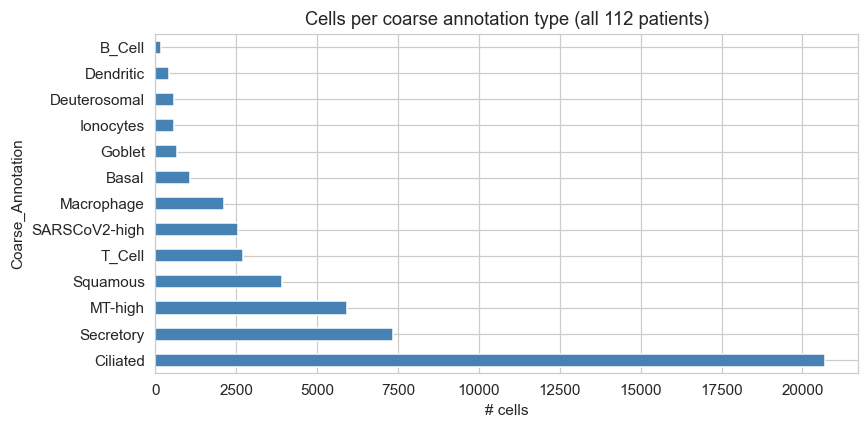

In [29]:
cell_type_counts = adata.obs[COARSE_COL].value_counts()
print(cell_type_counts)

fig, ax = plt.subplots(figsize=(8, 4))
cell_type_counts.plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("# cells")
ax.set_title("Cells per coarse annotation type (all 112 patients)")
plt.tight_layout()
plt.show()

## 1.6 — Visualize the UMAP

In [30]:
# Filter to COVID+ cells
adata_covid = adata[adata.obs["SARSCoV2_PCR_Status"] == "positive"].copy()

# Binary severity directly from WHO_Score_at_Peak
adata_covid.obs["severity"] = (adata_covid.obs["WHO_Score_at_Peak"] >= 5).astype(int)

print(f"COVID+ cells:    {adata_covid.n_obs:,}")
print(f"COVID+ patients: {adata_covid.obs['Participant'].nunique()}")
print(f"\nPatients per severity class:")
print(adata_covid.obs.groupby("severity")["Participant"].nunique())

COVID+ cells:    38,989
COVID+ patients: 86

Patients per severity class:
severity
0    32
1    54
Name: Participant, dtype: int64


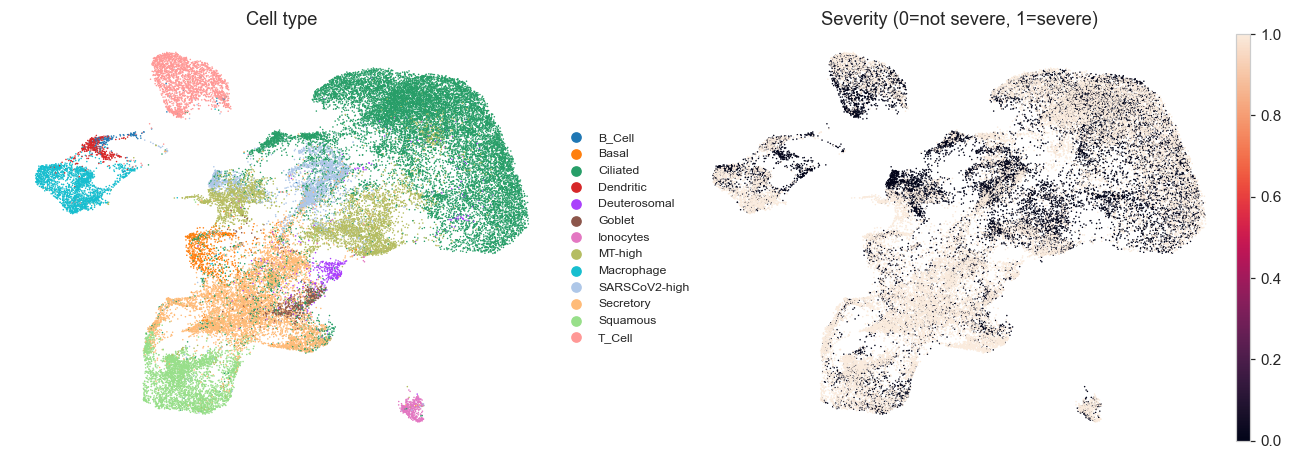

In [31]:
if "X_umap" in adata_covid.obsm: # type: ignore
    sc.pl.umap(
        adata_covid,
        color=[COARSE_COL, "severity"],
        legend_fontsize=8,
        frameon=False,
        ncols=2,
        title=["Cell type", "Severity (0=not severe, 1=severe)"],
        size=4,
    )


In [ ]:
adata_covid = adata[adata.obs["SARSCoV2_PCR_Status"] == "positive"].copy()

# Define binary severity directly from WHO_Score_at_Peak (already in obs)
adata_covid.obs["severity"] = (adata_covid.obs["WHO_Score_at_Peak"] >= 5).astype(int)

# Sanity check — should match Step 1 numbers exactly
print(f"COVID+ cells:    {adata_covid.n_obs:,}")
print(f"COVID+ patients: {adata_covid.obs['Participant'].nunique()}")
print(f"\nSeverity label distribution per cell:")
print(adata_covid.obs["severity"].value_counts())
print(f"\nPatients per severity class:")
print(adata_covid.obs.groupby("severity")["Participant"].nunique())

COVID+ cells:    38,989
COVID+ patients: 86

Severity label distribution per cell:
severity
1    22275
0    16714
Name: count, dtype: int64

Patients per severity class:
severity
0    32
1    54
Name: Participant, dtype: int64


## 1.7 — Save the filtered AnnData

In [ ]:
OUTPUT_PATH = "step2_covid_filtered.h5ad"
adata_covid.write_h5ad(OUTPUT_PATH)
print(f"Saved: {OUTPUT_PATH}")
print(f"  Shape: {adata_covid.n_obs:,} cells × {adata_covid.n_vars:,} genes")


Saved: step2_covid_filtered.h5ad
  Shape: 38,989 cells × 29,961 genes
  File size on disk: check the explorer — should be ~300-600 MB
